In [2]:
import torch
import lightning as L

from CausalSurv.data.data_utils import ESMEDataModule
from CausalSurv.model.DynaSurvCausal import CausalDynaSurv

import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
data_module = ESMEDataModule(
    data_dir="../data/model_entry_imputed_data_HR+HER2-_stable_types_categorized.parquet",
    config="../configs/data.toml",
)
data_module.prepare_data()
data_module.setup()
test_loader = data_module.test_dataloader()
treatment_dict = data_module.treatment_dict

T_treatment_category  lineid
CT+ANTI-ANGIO         1.0       1020
                      2.0        444
                      3.0        215
CT+ANTI-HER2          1.0         44
                      2.0         25
                      3.0         32
CT+IT                 1.0          6
                      2.0          6
                      3.0         17
CT+TT                 1.0          5
                      2.0         29
                      3.0         58
ET alone              1.0       4108
                      2.0       2475
                      3.0       1032
ET+ANTI-CDK wo CT     1.0       1562
                      2.0       1446
                      3.0        918
ET+TT                 1.0        193
                      2.0        526
                      3.0        439
MONOCT std alone      1.0       1097
                      2.0       1928
                      3.0       3424
NO TREATMENT          1.0         16
OTHER                 1.0        557
         

In [4]:
model = CausalDynaSurv.load_from_checkpoint("../scripts/logs/causal_esme/version_37/checkpoints/epoch=38-step=4290.ckpt")
model = model.to(device)

INFO:root:embed_LSTM initialized with x_embed_dim=4, p_embed_dim=3, hidden_length=6


In [5]:
import torch

batch = next(iter(test_loader))
XPd, sa_true, treatment_index, time, event = batch
XPd = XPd.to(device)

with torch.no_grad():
    batch_prediction = model.predict_counterfactual_survival(XPd)
patient_prediction = batch_prediction[0]
ones = torch.ones_like(patient_prediction[:, :, :1])
patient_prediction = torch.cat([ones, patient_prediction], dim=2)

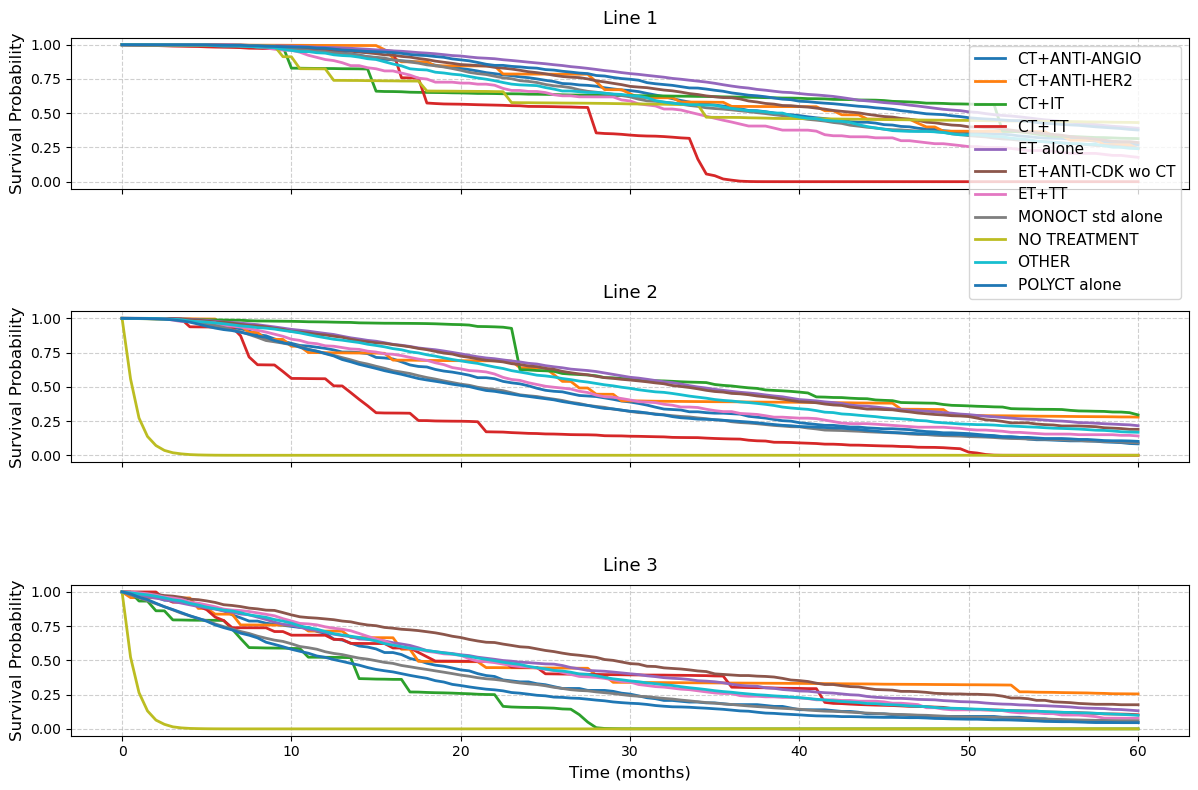

In [6]:
fig, ax = plt.subplots(nrows=patient_prediction.shape[0], ncols=1, figsize=(12, 8), sharex=True)

colors = plt.cm.tab10.colors  # Use a colormap for better distinction
import numpy as np
for i in range(patient_prediction.shape[0]):
    for j in range(patient_prediction.shape[1]):
        time_steps = np.arange(patient_prediction.shape[2]) * 0.5  # each step is half a month
        label = treatment_dict[j][2:]
        ax[i].plot(
            time_steps,
            patient_prediction[i, j, :].cpu().detach().numpy(),
            label=label,
            color=colors[j % len(colors)],
            linewidth=2
        )
    ax[i].set_ylabel("Survival Probability", fontsize=12)
    ax[i].grid(True, linestyle='--', alpha=0.6)
    ax[i].set_title(f"Line {i + 1}", fontsize=13, pad=10)
    if i == 0:
        ax[i].legend(fontsize=11, loc='upper right')
ax[-1].set_xlabel("Time (months)", fontsize=12)
plt.tight_layout()
plt.savefig("counterfactual_survival_curves.png", dpi=300)
plt.show()